<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana6/Exemplo_Dashboard_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# PROJETO FINAL - SEMANA 06: ENGENHARIA DE DADOS E VISUALIZAÇÃO
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Oculta avisos estéticos do Pandas

print("Iniciando o processamento do Pipeline de Dados...")

# ==============================================================================
# 1. SIMULAÇÃO DE BIG DATA (Gerando mais de 100 mil registros)
# ==============================================================================
np.random.seed(42)

# Simulando Sistema de Vendas (Mês 1 e Mês 2 separados)
n_vendas = 50000
dados_mes1 = pd.DataFrame({
    'ID_Transacao': range(1, n_vendas + 1),
    'ID_Cliente': np.random.randint(1000, 5000, n_vendas),
    'Data': pd.date_range(start='2024-01-01', periods=n_vendas, freq='2min'),
    'Valor_Compra': np.random.exponential(scale=150, size=n_vendas) + 20,
    'Qtd_Itens': np.random.randint(1, 10, n_vendas)
})

dados_mes2 = pd.DataFrame({
    'ID_Transacao': range(n_vendas + 1, (n_vendas*2) + 1),
    'ID_Cliente': np.random.randint(1000, 5000, n_vendas),
    'Data': pd.date_range(start='2024-02-01', periods=n_vendas, freq='2min'),
    'Valor_Compra': np.random.exponential(scale=180, size=n_vendas) + 20,
    'Qtd_Itens': np.random.randint(1, 15, n_vendas)
})

# Simulando Banco de Dados de Clientes (Cadastro)
dados_clientes = pd.DataFrame({
    'ID_Cliente': range(1000, 5000),
    'Idade': np.random.normal(35, 12, 4000).astype(int),
    'Regiao': np.random.choice(['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte'], 4000, p=[0.4, 0.2, 0.2, 0.1, 0.1]),
    'Tempo_Cadastro_Meses': np.random.randint(1, 60, 4000)
})

Iniciando o processamento do Pipeline de Dados...


In [2]:

# ==============================================================================
# 2. TRANSFORMAÇÕES E CRUZAMENTOS (A Mágica do Pandas)
# ==============================================================================
# A) pd.concat: Empilhando os meses
df_vendas = pd.concat([dados_mes1, dados_mes2], ignore_index=True)

# B) pd.merge: Cruzando Vendas com Cadastro de Clientes (PROCV)
df_master = pd.merge(df_vendas, dados_clientes, on='ID_Cliente', how='inner')

# C) np.where: Lógica Condicional Rápida
df_master['Ticket'] = np.where(df_master['Valor_Compra'] > 300, 'Ticket Alto', 'Ticket Baixo')

# D) np.select: Múltiplas Condições (Faixa Etária)
condicoes = [
    (df_master['Idade'] < 25),
    (df_master['Idade'] >= 25) & (df_master['Idade'] < 40),
    (df_master['Idade'] >= 40)
]
resultados = ['Geração Z', 'Millennials', 'Geração X+']
df_master['Geracao'] = np.select(condicoes, resultados, default='Desconhecido')

# E) .apply() com Lambda: Criando um "Score de Engajamento" matemático
df_master['Score_Engajamento'] = df_master.apply(
    lambda x: (x['Qtd_Itens'] * 2) + (x['Tempo_Cadastro_Meses'] * 0.5), axis=1
)

print(f"Processamento concluído! O Dataset possui {df_master.shape[0]} linhas e {df_master.shape[1]} colunas.")
print("Gerando o Dashboard Executivo. Aguarde...\n")

Processamento concluído! O Dataset possui 100000 linhas e 11 colunas.
Gerando o Dashboard Executivo. Aguarde...



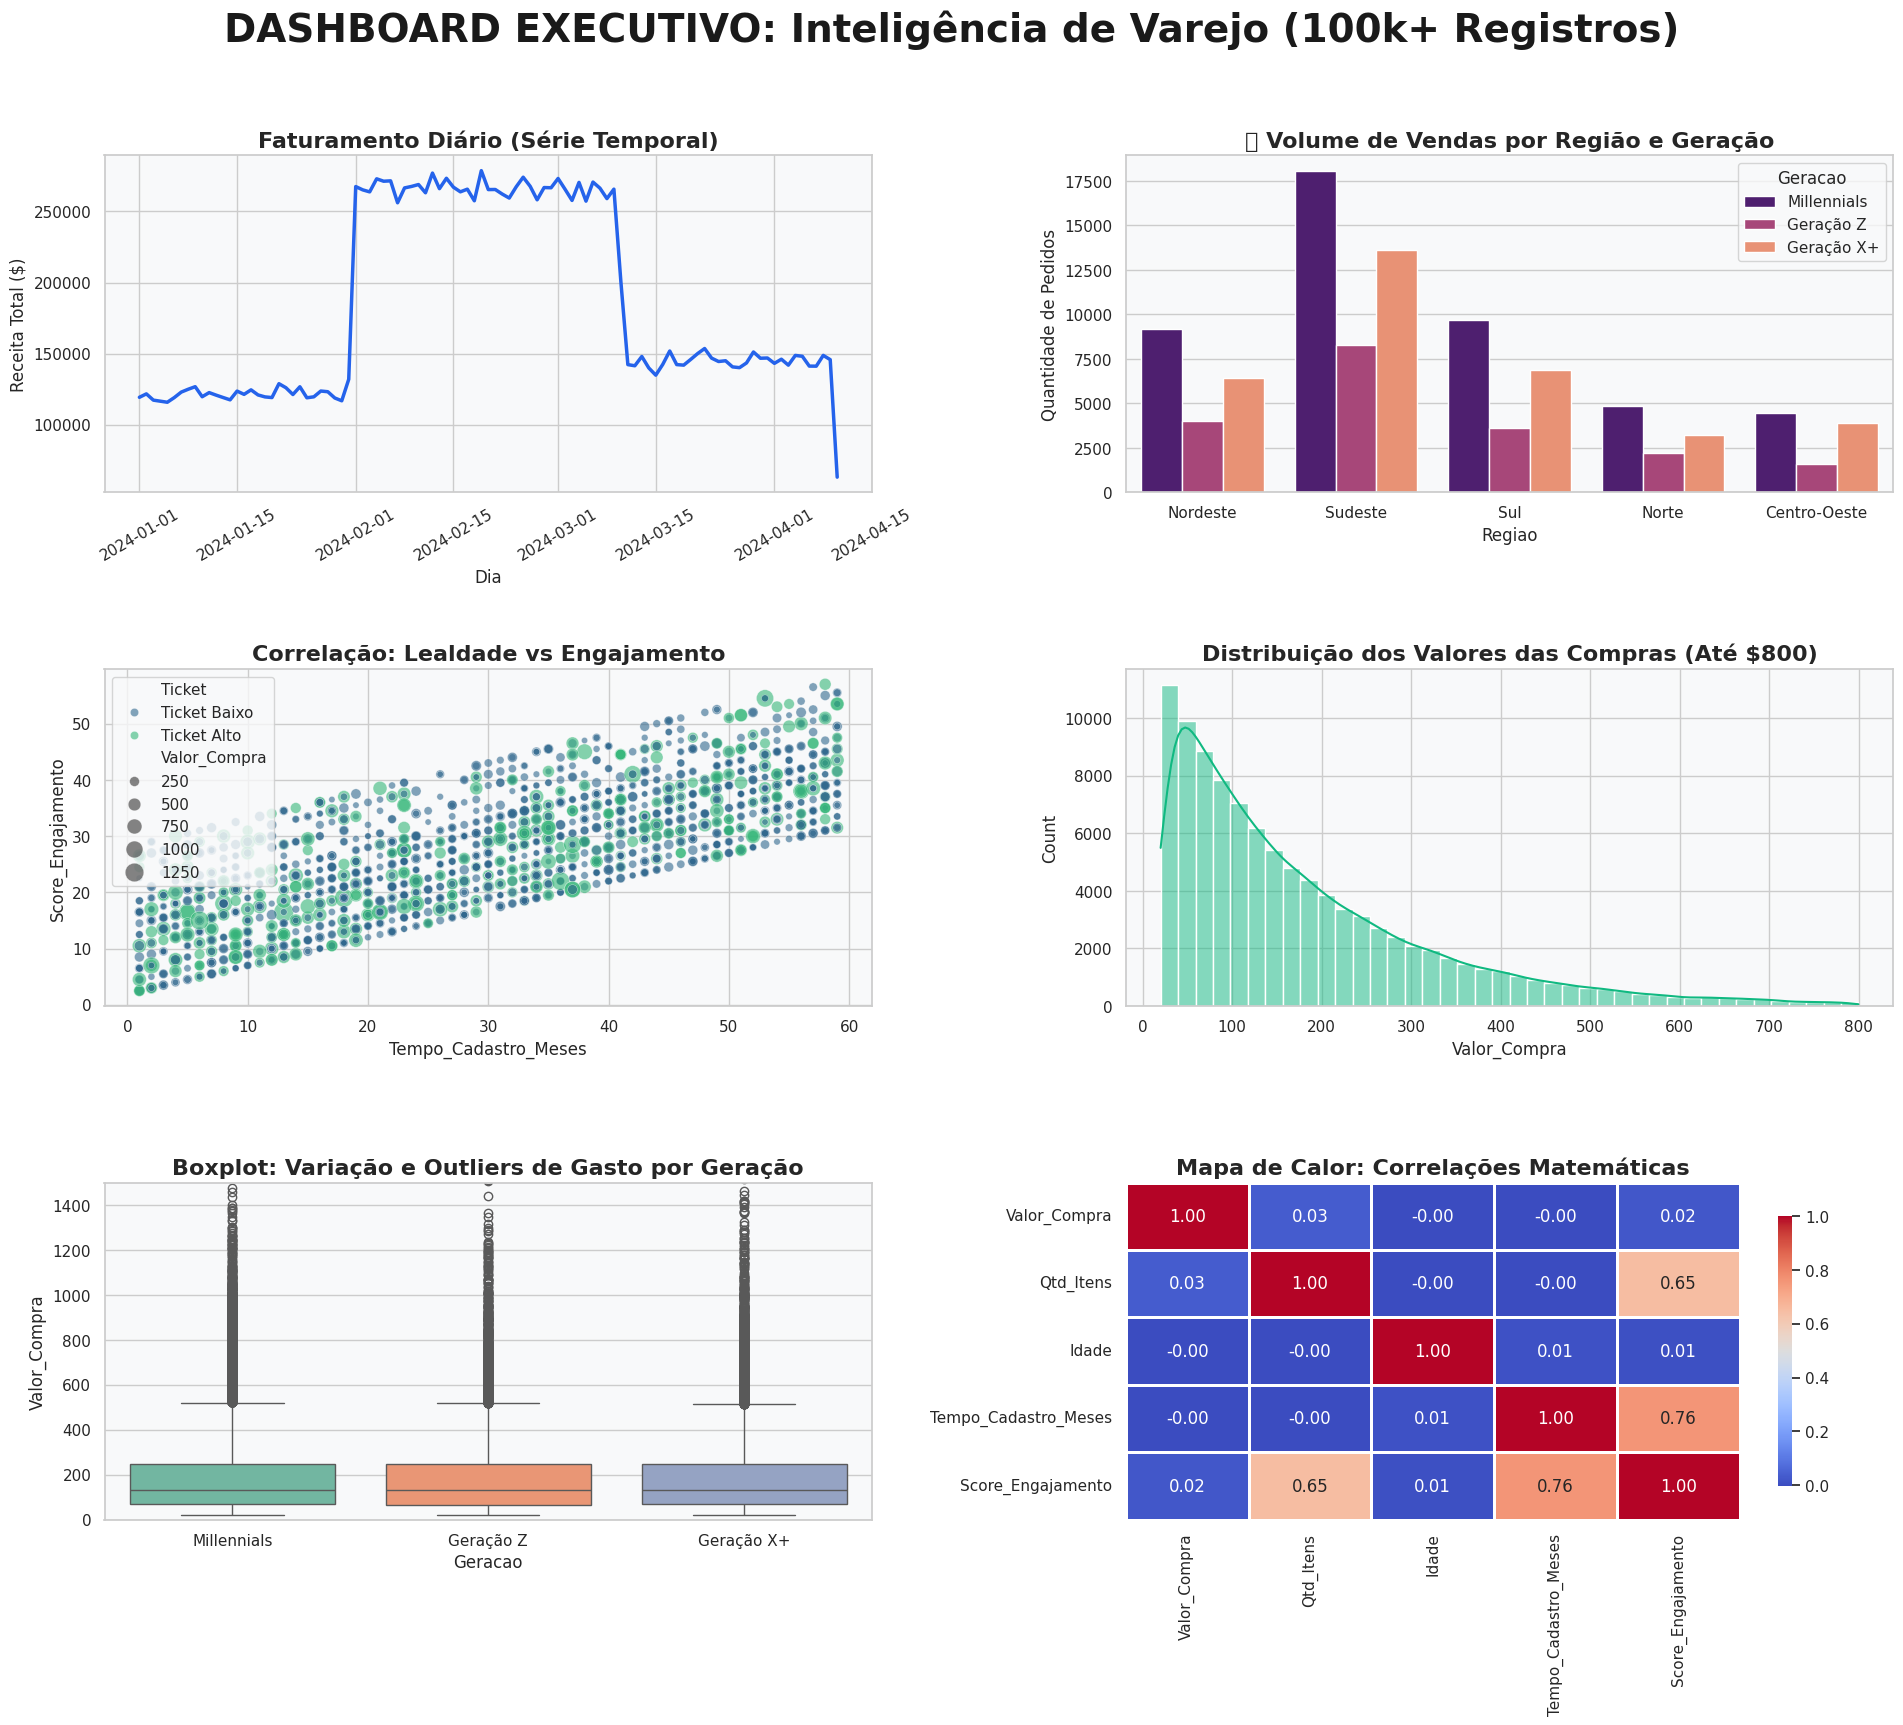

In [3]:

# ==============================================================================
# 3. DASHBOARD CORPORATIVO (Matplotlib + Seaborn)
# ==============================================================================
# Configuração estética
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#f8f9fa"})
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('DASHBOARD EXECUTIVO: Inteligência de Varejo (100k+ Registros)',
             fontsize=28, fontweight='bold', color='#1a1a1a', y=0.98)

# Para séries temporais ficarem mais limpas, vamos agrupar por dia
df_master['Dia'] = df_master['Data'].dt.floor('D')
vendas_diarias = df_master.groupby('Dia')['Valor_Compra'].sum().reset_index()

# ------------------------------------------------------------------
# [0, 0] Gráfico de Linha: Receita Diária
sns.lineplot(ax=axes[0, 0], data=vendas_diarias, x='Dia', y='Valor_Compra', color='#2563eb', linewidth=2.5)
axes[0, 0].set_title('Faturamento Diário (Série Temporal)', fontsize=16, fontweight='bold')
axes[0, 0].set_ylabel('Receita Total ($)')
axes[0, 0].tick_params(axis='x', rotation=30)

# ------------------------------------------------------------------
# [0, 1] Gráfico de Barras: Vendas por Região e Geração
sns.countplot(ax=axes[0, 1], data=df_master, x='Regiao', hue='Geracao', palette='magma')
axes[0, 1].set_title('👥 Volume de Vendas por Região e Geração', fontsize=16, fontweight='bold')
axes[0, 1].set_ylabel('Quantidade de Pedidos')

# ------------------------------------------------------------------
# [1, 0] Gráfico de Dispersão: Tempo de Cadastro vs Score de Engajamento
# Como temos 100 mil pontos, vamos usar uma amostra de 2000 para não virar um borrão na tela
amostra = df_master.sample(2000, random_state=42)
sns.scatterplot(ax=axes[1, 0], data=amostra, x='Tempo_Cadastro_Meses', y='Score_Engajamento',
                hue='Ticket', size='Valor_Compra', sizes=(20, 200), palette='viridis', alpha=0.6)
axes[1, 0].set_title('Correlação: Lealdade vs Engajamento', fontsize=16, fontweight='bold')

# ------------------------------------------------------------------
# [1, 1] Histograma: Distribuição dos Valores de Compra
# Limitando o eixo X para ver o "grosso" dos dados sem distorção dos milionários
sns.histplot(ax=axes[1, 1], data=df_master[df_master['Valor_Compra'] < 800],
             x='Valor_Compra', bins=40, kde=True, color='#10b981')
axes[1, 1].set_title('Distribuição dos Valores das Compras (Até $800)', fontsize=16, fontweight='bold')

# ------------------------------------------------------------------
# [2, 0] Boxplot: Caça aos Outliers por Geração
sns.boxplot(ax=axes[2, 0], data=df_master, x='Geracao', y='Valor_Compra', palette='Set2')
axes[2, 0].set_title('Boxplot: Variação e Outliers de Gasto por Geração', fontsize=16, fontweight='bold')
axes[2, 0].set_ylim(0, 1500) # Cortando o topo do gráfico para ver a caixa melhor

# ------------------------------------------------------------------
# [2, 1] Mapa de Calor (Heatmap): Matriz de Correlação
# Seleciona só as colunas numéricas para a IA não dar erro
colunas_numericas = df_master[['Valor_Compra', 'Qtd_Itens', 'Idade', 'Tempo_Cadastro_Meses', 'Score_Engajamento']]
matriz_corr = colunas_numericas.corr()

sns.heatmap(ax=axes[2, 1], data=matriz_corr, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=2, cbar_kws={"shrink": .8})
axes[2, 1].set_title('Mapa de Calor: Correlações Matemáticas', fontsize=16, fontweight='bold')

# ------------------------------------------------------------------
# Finalização e Ajuste de Layout
plt.tight_layout(pad=3.5)
plt.show()